In [1]:
import pyvista as pv
import numpy as np
import subprocess
import time
import pandas as pd

In [17]:
start_time = time.perf_counter()
result = subprocess.run(
    ['/workspaces/nm/build/pde/example/mf/non/e_pde_mf_non'],
    cwd='.',
    capture_output=True,
    text=True,
    check=True,
    env={
      "OMP_NUM_THREADS": "4"
    })
end_time = time.perf_counter()

print(result.stdout)
print(result.stderr)
print(f"Execution time: {end_time - start_time:.4f} seconds")

[umsh][tel] zone: 18
[umsh][tel] vtx: 11850
[umsh][tel] qud: 11622
[umsh][tel] seg: 454
[vec]|[iss-rlx] ok
[vec]|[iss-rlx] itr: 18
[vec]|[iss-rlx] err: 4.966e-11
[apx][int-cub] ok
[non] itr: 0, err: 1.0000000e+00[iss][gmr] itr: 2999
[iss][gmr] err: 1.5626057e+02
[non] itr: 1, err: 6.9809391e-02[iss][gmr] itr: 2999
[iss][gmr] err: 9.9103498e+03
[non] itr: 2, err: 1.2487332e-01[iss][gmr] itr: 2999
[iss][gmr] err: 1.5833506e+04
[non] itr: 3, err: 1.1112241e-02[iss][gmr] itr: 2999
[iss][gmr] err: 2.7674153e+04
[non] itr: 4, err: 1.4824681e-01[iss][gmr] itr: 2999
[iss][gmr] err: 3.9343745e+04
[non] itr: 5, err: 2.7219835e-01[iss][gmr] itr: 2999
[iss][gmr] err: 4.9403011e+04
[non] itr: 6, err: 1.0888151e+00[iss][gmr] itr: 2999
[iss][gmr] err: 4.1338393e+04
[non] itr: 7, err: 1.2599832e+00[iss][gmr] itr: 2999
[iss][gmr] err: 3.9052884e+04
[non] itr: 8, err: 4.1091860e+00[iss][gmr] itr: 2999
[iss][gmr] err: 3.8528810e+04
[non] itr: 9, err: 5.0812745e+00[iss][gmr] itr: 2999
[iss][gmr] err: 4.96

In [15]:
df = pd.read_csv('out/control-points.csv')
pd.options.display.max_columns = len(df.columns)

print(df.to_markdown(floatfmt='.3e', tablefmt='github'))

|    |         x |         y |         Az |         Bx |        By |        Bm |
|----|-----------|-----------|------------|------------|-----------|-----------|
|  0 | 2.520e-02 | 1.600e-03 |  3.240e+00 |  2.159e+01 | 2.856e+02 | 2.864e+02 |
|  1 | 3.350e-02 | 2.700e-03 |  8.782e-01 |  7.627e+00 | 2.875e+02 | 2.876e+02 |
|  2 | 3.500e-02 | 9.000e-04 |  4.379e-01 |  5.105e+00 | 2.844e+02 | 2.845e+02 |
|  3 | 3.650e-02 | 2.700e-03 |  1.586e-02 |  2.582e+00 | 2.875e+02 | 2.875e+02 |
|  4 | 4.290e-02 | 3.500e-03 | -1.830e+00 | -8.181e+00 | 2.888e+02 | 2.889e+02 |


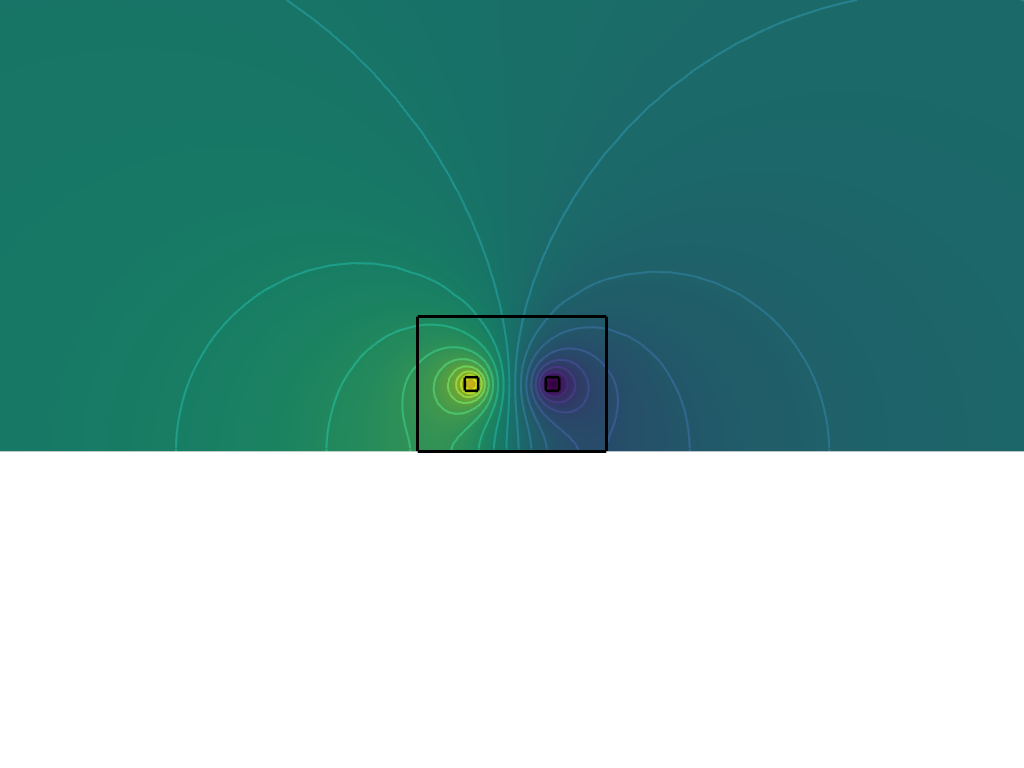

In [26]:
grid_az = pv.CGNSReader('out/emf-0.cgns').read().combine()
grid_bx = pv.CGNSReader('out/emf-1.cgns').read().combine()
grid_by = pv.CGNSReader('out/emf-2.cgns').read().combine()
grid_bm = pv.CGNSReader('out/emf-3.cgns').read().combine()

bx = grid_bx['Bx']
by = grid_by['By']
bm = grid_bm['Bm']

isolines = grid_az.contour(isosurfaces=20, scalars='Az')

ids = np.arange(0, grid_az.n_points, 20)
arrow_src = pv.PolyData(grid_az.points[ids])
arrow_src['B'] = np.c_[bx, by, np.zeros_like(bx)][ids]
arrow_src['Bm'] = bm[ids]

arrows = arrow_src.glyph(
    orient='B',
    scale='Bm',
    factor=0.00002
)

plotter = pv.Plotter()

plotter.add_mesh(
    grid_az,
    scalars='Az',
    # show_edges=True,
    cmap='viridis',
    show_scalar_bar=False
)

plotter.add_mesh(
    isolines,
    scalars='Az',
    line_width=2,
    cmap='viridis',
    show_scalar_bar=False
)

# plotter.add_mesh(
#     arrows,
#     color='white',
#     lighting=False
# )

plotter.add_mesh(
    pv.Rectangle([[0.07, 0, 0], [0.07, 0.05, 0], [0, 0.05, 0]]),
    line_width=3,
    color='black',
    style='wireframe'
)

plotter.add_mesh(
    pv.Rectangle([[0.0225, 0.0225, 0], [0.0225, 0.0275, 0], [0.0175, 0.0275, 0]]),
    line_width=3,
    color='black',
    style='wireframe'
)

plotter.add_mesh(
    pv.Rectangle([[0.0525, 0.0225, 0], [0.0525, 0.0275, 0], [0.0475, 0.0275, 0]]),
    line_width=3,
    color='black',
    style='wireframe'
)

plotter.camera_position = 'xy'
plotter.reset_camera(bounds=[-0.1, 0.17, 0.0, 0.05, 0, 0])
plotter.screenshot('result.png', transparent_background=True)
plotter.show(jupyter_backend='static')